# 1. Introduction: Analyzing CNN Embedding Spaces on CIFAR-10

This notebook explores the relationship between the geometric structure of a Convolutional Neural Network's (CNN) embedding space and its classification performance.

### Objectives:
1.  **Train CNNs:** Train several CNN models on the CIFAR-10 dataset to achieve a range of test accuracies.
2.  **Extract Embeddings:** For each trained model, extract feature vectors (embeddings) from the penultimate layer for all images in the training set.
3.  **Compute Spatial Metrics:** Quantify the quality of the embedding space using metrics that measure class separation, such as:
    * **Intra-class distance:** How tightly clustered are embeddings of the same class?
    * **Inter-class distance:** How far apart are the clusters of different classes?
    * **Silhouette Score:** A composite measure of cluster cohesion and separation.
    * **Fisher's Discriminant Ratio:** The ratio of between-class scatter to within-class scatter.
4.  **Analyze Correlation:** Systematically analyze and visualize the correlation between these spatial metrics and the model's final test-set accuracy.
5.  **Interpret Results:** Discuss the findings to understand how representation learning and class separability in the feature space relate to a model's generalization capability.

We will use PyTorch for model training, scikit-learn for metrics, and matplotlib for visualization. All random processes are seeded for reproducibility.

In [1]:
# Import necessary libraries and set up the environment for reproducibility.

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.decomposition import PCA
import random
import os
from tqdm import tqdm
import json

# --- Configuration ---
# Set a seed for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Set device to 'cpu' as we are optimizing for a CPU-only environment.
device = torch.device("cpu")
print(f"Using device: {device}")

# --- Paths and Settings ---
RESULTS_FILE = 'experiment_results_architecture.csv'
MODELS_DIR = 'saved_models_architecture'
os.makedirs(MODELS_DIR, exist_ok=True) # Directory to save model checkpoints

# Set to True to re-run all experiments even if results file exists
FORCE_RERUN = False

Using device: cpu


# 3. Data Preparation

We will download the CIFAR-10 dataset using `torchvision`. Standard data transformations are applied:
- **Training set:** We apply simple data augmentation (RandomCrop and RandomHorizontalFlip) to improve model robustness.
- **Test set:** We only apply normalization, as augmentation is not used during evaluation.

Normalization uses the standard mean and standard deviation for the CIFAR-10 dataset.

In [2]:
# Define data transformations
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std = [0.2470, 0.2435, 0.2616]

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

# Download CIFAR-10 dataset
try:
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
except Exception as e:
    print(f"Failed to download CIFAR-10, attempting to load from local. Error: {e}")
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)


# Create DataLoaders for training, testing, and embedding extraction
trainset_for_embedding = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_test)

train_loader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=0, pin_memory=False)
embedding_loader = DataLoader(trainset_for_embedding, batch_size=256, shuffle=False, num_workers=0, pin_memory=False)


# Define class names
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 4. Model Definition

We define a simple VGG-style CNN. The model is structured with a `features` extractor and a `classifier`. This separation makes it easy to access the embeddings from the penultimate layer (i.e., the output of the `features` module before the final linear layer).

**Why the penultimate layer?** This layer's output is a high-level feature representation that the model has learned to be linearly separable by the final classification layer. Its geometry is expected to be highly correlated with the model's ability to distinguish between classes.

In [3]:
class ConfigurableCNN(nn.Module):
    """A CNN that can be configured with different depths and widths."""
    def __init__(self, channels_config, num_classes=10):
        super(ConfigurableCNN, self).__init__()
        
        layers = []
        in_channels = 3
        
        # Create convolutional blocks based on the channels_config
        for out_channels in channels_config:
            layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            ])
            in_channels = out_channels
            
        self.features = nn.Sequential(*layers)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # The classifier's input size depends on the last block's channel count
        self.classifier = nn.Linear(in_channels, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        embedding = torch.flatten(x, 1)
        logits = self.classifier(embedding)
        return logits, embedding

# Test the model with a dummy input
dummy_config = [32, 64] # A small configuration for testing
model = ConfigurableCNN(channels_config=dummy_config).to(device)
dummy_input = torch.randn(2, 3, 32, 32).to(device)
logits, embedding = model(dummy_input)
print(f"Model created with channels: {dummy_config}")
print(f"Model output shape (logits): {logits.shape}")
print(f"Model output shape (embedding): {embedding.shape}")

Model created with channels: [32, 64]
Model output shape (logits): torch.Size([2, 10])
Model output shape (embedding): torch.Size([2, 64])


# 5. Training and Evaluation Loop

Here we define the core functions for training and testing the model.
- `train_epoch`: Processes one epoch of training data, computes loss, and updates model weights.
- `evaluate`: Calculates the model's accuracy on a given dataset (e.g., the test set).
- `train_model`: The main function that orchestrates the entire training process over multiple epochs.

In [4]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for one epoch."""
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate(model, dataloader, device):
    """Evaluates the model's accuracy on the given dataset."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits, _ = model(inputs)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def train_model(config):
    """Main training loop."""
    print(f"\n--- Training with config: {config['name']} ---")

    # Build model based on architecture config
    model = ConfigurableCNN(channels_config=config['arch']['channels']).to(device)
    
    # Apply JIT compilation to the model for faster execution
    model = torch.jit.script(model)

    optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0

    for epoch in range(config['epochs']):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_acc = evaluate(model, test_loader, device)
        print(f"Epoch {epoch+1}/{config['epochs']} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}%")
        if test_acc > best_acc:
            best_acc = test_acc

    print(f"Finished Training. Final Test Accuracy: {best_acc:.2f}%")
    return model, best_acc

# 6. Embedding Extraction

This function takes a trained model and a `DataLoader` (specifically, one without data augmentations) and computes the embeddings for every sample. It returns two NumPy arrays: one for the embeddings and one for the corresponding labels.

In [5]:
def extract_embeddings(model, dataloader, device):
    """Extracts embeddings and labels for the given dataset."""
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Extracting Embeddings"):
            inputs = inputs.to(device)
            _, embeddings_batch = model(inputs)
            all_embeddings.append(embeddings_batch.cpu().numpy())
            all_labels.append(labels.numpy())

    embeddings_np = np.concatenate(all_embeddings, axis=0)
    labels_np = np.concatenate(all_labels, axis=0)
    return embeddings_np, labels_np

# 7. Spatial Metrics Computation

We define functions to calculate various metrics that describe the geometry of the embedding space.

### Metrics:
1.  **Intra-Class Distance:** The average Euclidean distance of each sample to its class's centroid. A smaller value indicates tighter, more compact clusters.
    $$ d_{intra} = \frac{1}{C} \sum_{c=0}^{C-1} \left( \frac{1}{N_c} \sum_{i \in \text{class } c} || \mathbf{x}_i - \boldsymbol{\mu}_c ||_2 \right) $$
    where $\boldsymbol{\mu}_c$ is the centroid of class $c$.

2.  **Inter-Class Distance:** The average Euclidean distance between the centroids of all pairs of classes. A larger value indicates better separation between classes.
    $$ d_{inter} = \frac{2}{C(C-1)} \sum_{i=0}^{C-1} \sum_{j=i+1}^{C-1} || \boldsymbol{\mu}_i - \boldsymbol{\mu}_j ||_2 $$

3.  **Fisher's Discriminant Ratio (FDR):** The ratio of between-class scatter (variance) to within-class scatter. A higher FDR is better.
    $$ \text{FDR} = \frac{\text{tr}(\mathbf{S}_B)}{\text{tr}(\mathbf{S}_W)} $$
    where $\mathbf{S}_W = \sum_c \sum_{i \in c} (\mathbf{x}_i - \boldsymbol{\mu}_c)(\mathbf{x}_i - \boldsymbol{\mu}_c)^T$ is the within-class scatter matrix and $\mathbf{S}_B = \sum_c N_c (\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^T$ is the between-class scatter matrix.

4.  **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters. The score ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

In [6]:
def compute_centroids(embeddings, labels):
    """Computes class centroids."""
    centroids = []
    for i in range(len(classes)):
        centroids.append(embeddings[labels == i].mean(axis=0))
    return np.array(centroids)

def compute_intra_class_distance(embeddings, labels, centroids):
    """Computes average intra-class distance."""
    avg_distances = []
    for i in range(len(classes)):
        class_embeddings = embeddings[labels == i]
        distances = pairwise_distances(class_embeddings, centroids[i].reshape(1, -1))
        avg_distances.append(distances.mean())
    return np.mean(avg_distances)

def compute_inter_class_distance(centroids):
    """Computes average inter-class distance from centroids."""
    distances = pairwise_distances(centroids)
    return distances[np.triu_indices(len(classes), k=1)].mean()

def compute_fisher_discriminant_ratio(embeddings, labels, centroids):
    """Computes the ratio of traces of between-class and within-class scatter."""
    num_classes = len(centroids)
    d = embeddings.shape[1]
    sw = np.zeros((d, d))
    for i in range(num_classes):
        class_embeddings = embeddings[labels == i]
        diff = class_embeddings - centroids[i]
        sw += diff.T @ diff
    overall_mean = embeddings.mean(axis=0)
    sb = np.zeros((d, d))
    for i in range(num_classes):
        n = (labels == i).sum()
        diff = (centroids[i] - overall_mean).reshape(d, 1)
        sb += n * (diff @ diff.T)
    return np.trace(sb) / np.trace(sw)

def compute_all_metrics(embeddings, labels):
    """Computes and returns a dictionary of all spatial metrics."""
    centroids = compute_centroids(embeddings, labels)
    metrics = {}
    metrics['intra_dist'] = compute_intra_class_distance(embeddings, labels, centroids)
    metrics['inter_dist'] = compute_inter_class_distance(centroids)
    metrics['fisher_ratio'] = compute_fisher_discriminant_ratio(embeddings, labels, centroids)
    
    sample_size = 5000
    if len(embeddings) > sample_size:
        indices = np.random.choice(len(embeddings), sample_size, replace=False)
        sampled_embeddings, sampled_labels = embeddings[indices], labels[indices]
    else:
        sampled_embeddings, sampled_labels = embeddings, labels
        
    metrics['silhouette'] = silhouette_score(sampled_embeddings, sampled_labels)
    return metrics

# 8. Experimental Protocol

To understand how these metrics relate to performance, we need to generate multiple models with varying test accuracies. We can achieve this by training under different conditions. Here, we'll vary the **learning rate** and the **number of training epochs**.

For each configuration, we will:
1. Train a new model from scratch.
2. Record its final test accuracy.
3. Extract embeddings from the training set.
4. Compute all spatial metrics.
5. Store the results in a list, which will later be converted to a Pandas DataFrame.

To save time, we first check if a results file (`experiment_results_architecture.csv`) exists. If it does, we load it instead of re-running the experiments.

In [7]:
def save_model(model, path):
    """Saves the model's state dictionary."""
    print(f"Saving model to {path}...")
    torch.save(model.state_dict(), path)

def load_model(model_arch, path, device):
    """Loads a model's state dictionary into a new model instance."""
    if os.path.exists(path):
        print(f"Loading model from {path} with arch: {model_arch}...")
        # Build the model with the correct architecture first
        model = ConfigurableCNN(channels_config=model_arch).to(device)
        model.load_state_dict(torch.load(path, map_location=device))
        model = torch.jit.script(model) # Re-apply JIT compilation
        return model
    else:
        print(f"Model path {path} does not exist.")
        return None

# --- Experiment Configurations ---
experiment_configs = [
    # --- Tiny Models (fastest to train) ---
    {'name': 'Tiny_Fast', 'lr': 0.01, 'epochs': 5, 'arch': {'channels': [16, 32]}},
    {'name': 'Tiny_Slow', 'lr': 0.05, 'epochs': 8, 'arch': {'channels': [32, 64]}},
    
    # --- Small Models ---
    {'name': 'Small_Fast', 'lr': 0.01, 'epochs': 10, 'arch': {'channels': [32, 64, 128]}},
    {'name': 'Small_Slow', 'lr': 0.05, 'epochs': 12, 'arch': {'channels': [32, 64, 128]}},

    # --- Medium Models ---
    {'name': 'Medium_Fast', 'lr': 0.01, 'epochs': 12, 'arch': {'channels': [64, 128, 256]}},
    {'name': 'Medium_Slow', 'lr': 0.05, 'epochs': 15, 'arch': {'channels': [64, 128, 256]}},
    
    # --- Wider, Shallower Model ---
    {'name': 'Wide_Shallow', 'lr': 0.01, 'epochs': 12, 'arch': {'channels': [128, 256]}},
    
    # --- Deeper, Narrower Model ---
    {'name': 'Deep_Narrow', 'lr': 0.01, 'epochs': 15, 'arch': {'channels': [32, 32, 64, 64]}},
]

results = []

if os.path.exists(RESULTS_FILE) and not FORCE_RERUN:
    print(f"Loading existing results from {RESULTS_FILE}...")
    results_df = pd.read_csv(RESULTS_FILE)
else:
    for config in experiment_configs:
        model, test_acc = train_model(config)
        
        # Use config name for unique model path
        model_filename = f"model_{config['name']}.pth"
        model_path = os.path.join(MODELS_DIR, model_filename)
        save_model(model, model_path)
        
        embeddings_train, labels_train = extract_embeddings(model, embedding_loader, device)
        spatial_metrics = compute_all_metrics(embeddings_train, labels_train)
        
        run_result = {
            'name': config['name'],
            'lr': config['lr'],
            'epochs': config['epochs'],
            'architecture': json.dumps(config['arch']), # Store arch config
            'test_accuracy': test_acc,
            'model_path': model_path,
            **spatial_metrics
        }
        results.append(run_result)
        
        print("Metrics for this run:", {k: f"{v:.4f}" for k, v in spatial_metrics.items()})

    results_df = pd.DataFrame(results)
    results_df.to_csv(RESULTS_FILE, index=False)

print("\n--- Experimental Results ---")
print(results_df.round(4))

Loading existing results from experiment_results_architecture.csv...

--- Experimental Results ---
           name    lr  epochs                    architecture  test_accuracy  \
0     Tiny_Fast  0.01       5          {"channels": [16, 32]}          56.42   
1     Tiny_Slow  0.05       8          {"channels": [32, 64]}          67.41   
2    Small_Fast  0.01      10     {"channels": [32, 64, 128]}          80.70   
3    Small_Slow  0.05      12     {"channels": [32, 64, 128]}          80.47   
4   Medium_Fast  0.01      12    {"channels": [64, 128, 256]}          82.93   
5   Medium_Slow  0.05      15    {"channels": [64, 128, 256]}          84.92   
6  Wide_Shallow  0.01      12        {"channels": [128, 256]}          72.86   
7   Deep_Narrow  0.01      15  {"channels": [32, 32, 64, 64]}          83.95   

                                         model_path  intra_dist  inter_dist  \
0     saved_models_architecture/model_Tiny_Fast.pth      2.7156      3.7067   
1     saved_models_arc

# 9. Correlation Analysis

Now, we analyze the relationship between the computed spatial metrics and the test accuracy.

We will create scatter plots for each metric against test accuracy and compute the Pearson correlation coefficient to quantify these relationships.


--- Correlation with Test Accuracy ---
intra_dist      0.577838
inter_dist      0.713822
fisher_ratio    0.781847
silhouette      0.927588
Name: test_accuracy, dtype: float64


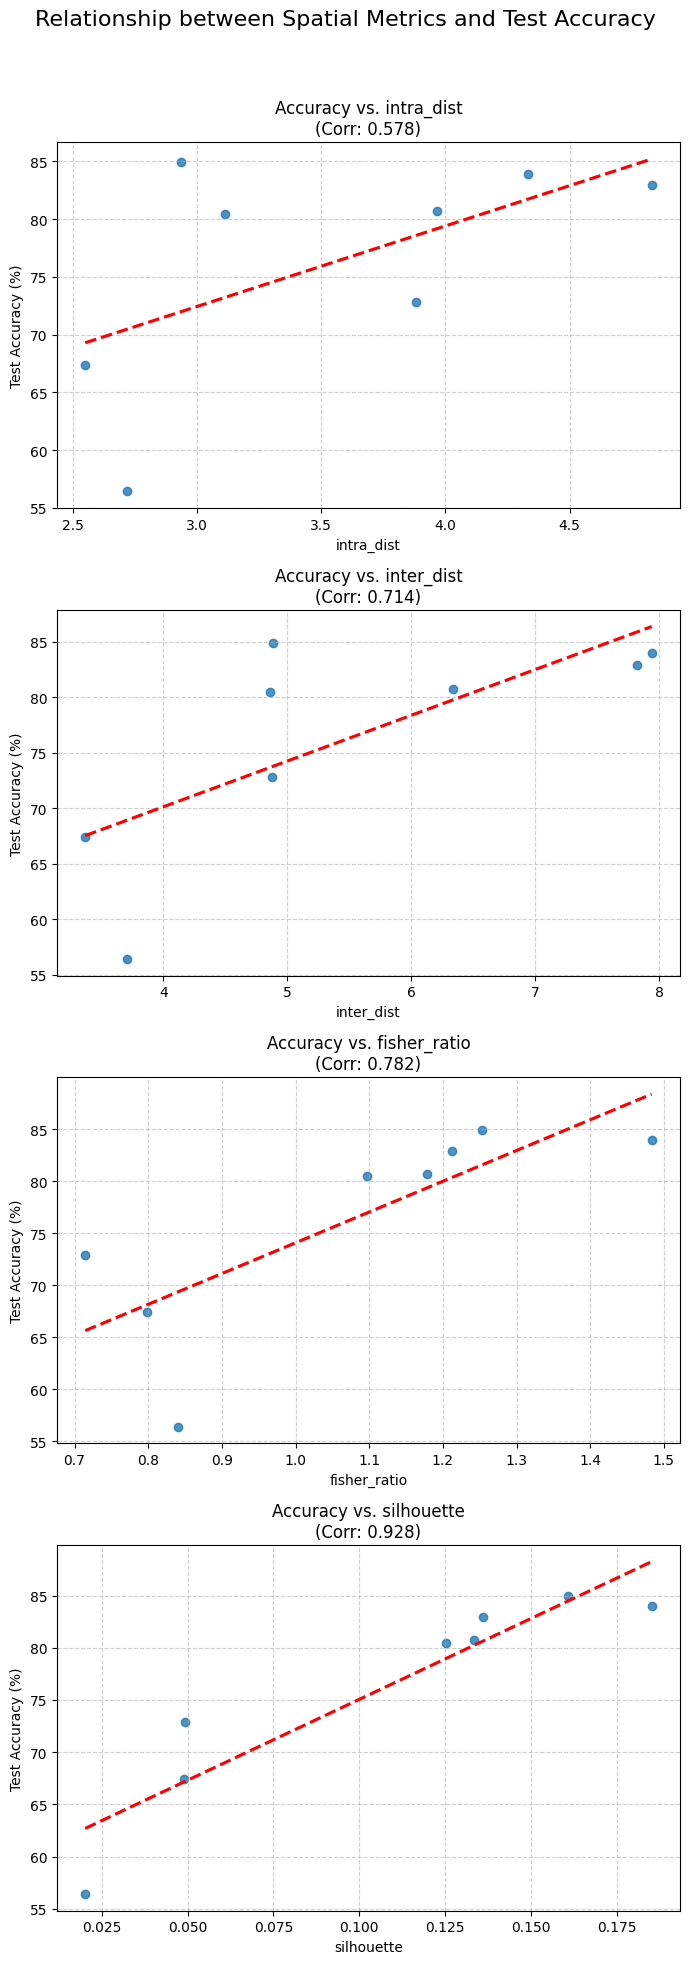

In [8]:
if not results_df.empty:
    metrics_to_plot = ['intra_dist', 'inter_dist', 'fisher_ratio', 'silhouette']
    
    correlations = results_df.corr(numeric_only=True)['test_accuracy'].loc[metrics_to_plot]
    print("\n--- Correlation with Test Accuracy ---")
    print(correlations)
    
    num_metrics = len(metrics_to_plot)
    fig, axes = plt.subplots(num_metrics, 1, figsize=(7, 5 * num_metrics))
    fig.suptitle('Relationship between Spatial Metrics and Test Accuracy', fontsize=16)
    
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i]
        sns.regplot(x=metric, y='test_accuracy', data=results_df, ax=ax, ci=None,
                    line_kws={'color': 'red', 'linestyle': '--'})
        ax.set_title(f'Accuracy vs. {metric}\n(Corr: {correlations[metric]:.3f})')
        ax.set_xlabel(metric)
        ax.set_ylabel('Test Accuracy (%)')
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
else:
    print("Results DataFrame is empty. Run experiments to generate data.")

# 10. Visualization of Embedding Space

To gain a more intuitive understanding of the embedding space, we can visualize it. We'll take the embeddings from our **best-performing model** and use Principal Component Analysis (PCA) to reduce their dimensionality to 2D. This allows us to plot the class clusters.

We will also visualize:
- The distribution of intra-class distances.
- A heatmap of the distances between class centroids.

Visualizing embeddings for the best model: Medium_Slow (Accuracy: 84.92%)
Loading model from saved_models_architecture/model_Medium_Slow.pth with arch: [64, 128, 256]...


Extracting Embeddings: 100%|██████████| 196/196 [02:49<00:00,  1.16it/s]



Performing PCA for 2D visualization...


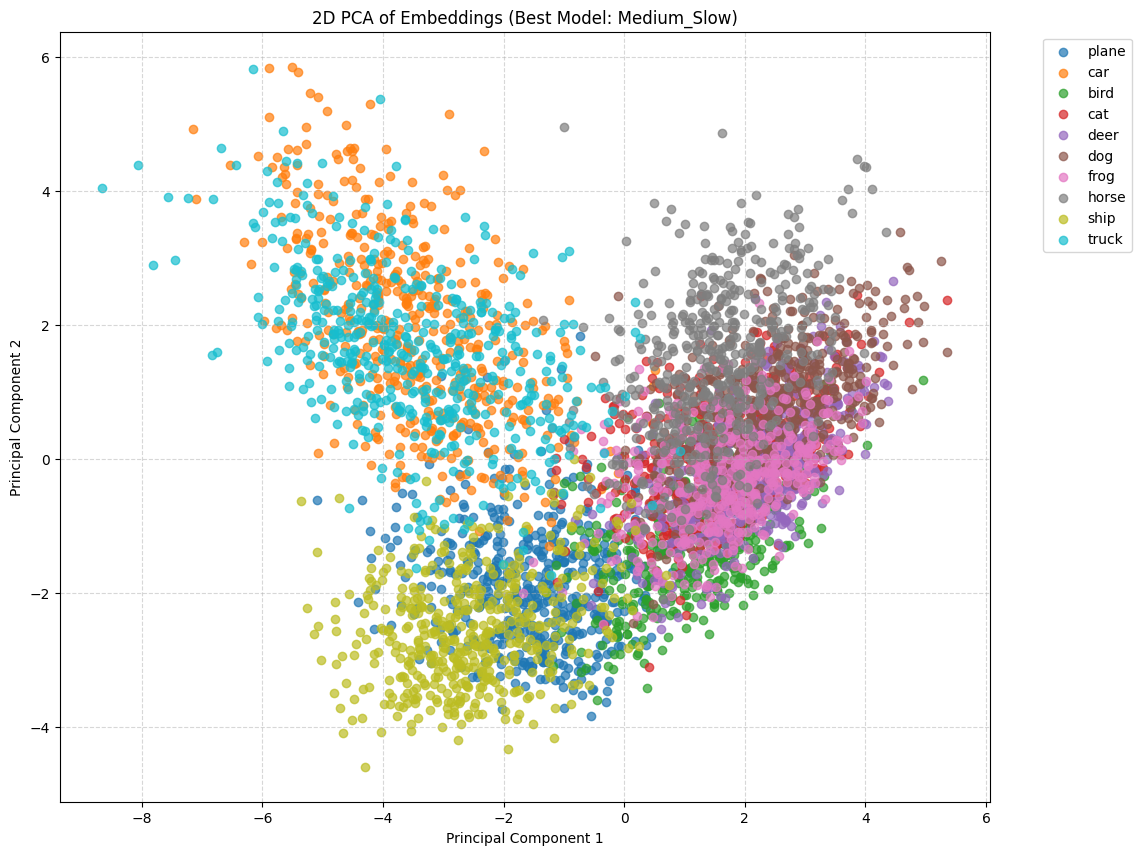

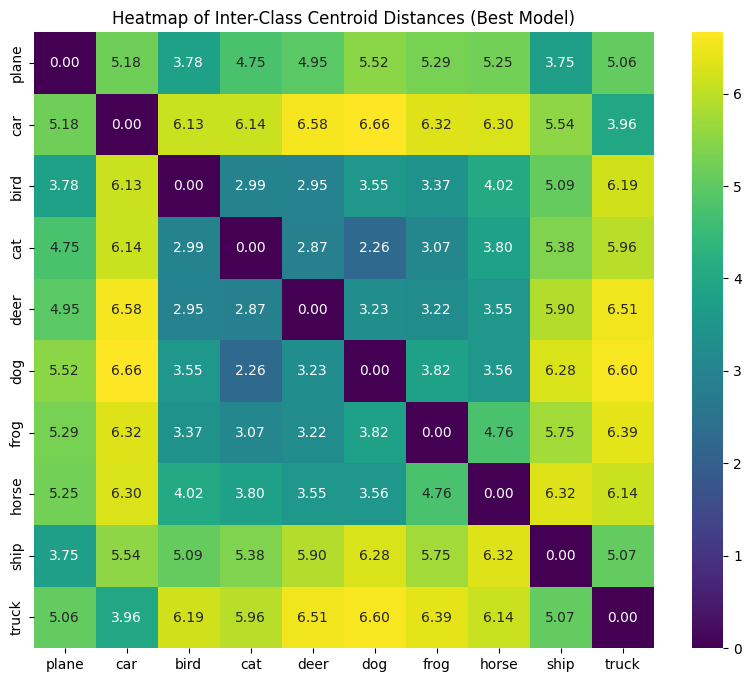

In [9]:
if not results_df.empty:
    best_run = results_df.loc[results_df['test_accuracy'].idxmax()]
    print(f"Visualizing embeddings for the best model: {best_run['name']} (Accuracy: {best_run['test_accuracy']:.2f}%)")

    # Load the architecture from the results file
    best_model_path = best_run['model_path']
    best_model_arch_str = str(best_run['architecture'])
    best_model_arch = json.loads(best_model_arch_str)['channels']
    
    # Load the best model with its specific architecture
    best_model = load_model(best_model_arch, best_model_path, device)
    
    if best_model:
        embeddings, labels = extract_embeddings(best_model, embedding_loader, device)

        # 1. Visualize with PCA
        print("\nPerforming PCA for 2D visualization...")
        pca = PCA(n_components=2)
        # Use a smaller subset for faster PCA and clearer plotting
        subset_indices = np.random.choice(len(embeddings), 5000, replace=False)
        embeddings_subset = embeddings[subset_indices]
        labels_subset = labels[subset_indices]
        
        embeddings_2d = pca.fit_transform(embeddings_subset)

        plt.figure(figsize=(12, 10))
        for i, class_name in enumerate(classes):
            class_indices = (labels_subset == i)
            plt.scatter(embeddings_2d[class_indices, 0], embeddings_2d[class_indices, 1], label=class_name, alpha=0.7)
        
        plt.title(f'2D PCA of Embeddings (Best Model: {best_run["name"]})')
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

        # 2. Visualize Centroid Distances
        centroids = compute_centroids(embeddings, labels)
        centroid_distances = pairwise_distances(centroids)

        plt.figure(figsize=(10, 8))
        sns.heatmap(centroid_distances, annot=True, fmt=".2f", cmap="viridis",
                    xticklabels=classes, yticklabels=classes)
        plt.title('Heatmap of Inter-Class Centroid Distances (Best Model)')
        plt.show()

else:
    print("Cannot perform visualization because results are empty.")